## Importy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Ładowanie danych

In [2]:
fleetrouter_static = pd.read_csv('~/SoftwareRequirements/Results/FleetRouter-static.csv').rename(columns=
    {'Unnamed: 2': 'Input_tokens', 'Unnamed: 3': 'Output_tokens',
     'Unnamed: 4': 'Cache_read_tokens', 'Unnamed: 5': 'Cache_create_tokens',
     'Unnamed: 6': 'Tokens_summary', 'Unnamed: 7': 'Security_low',
     'Unnamed: 8': 'Security_medium', 'Unnamed: 9': 'Security_high',
     'Unnamed: 10': 'Security_summary', 'Unnamed: 11': 'Reliability_low',
     'Unnamed: 12': 'Reliability_medium', 'Unnamed: 13': 'Reliability_high',
     'Unnamed: 14': 'Reliability_summary', 'Unnamed: 15': 'Maintainability_low',
     'Unnamed: 16': 'Maintainability_medium', 'Unnamed: 17': 'Maintainability_high',
     'Unnamed: 18': 'Maintainability_summary'}
).drop([0,1]).reset_index(drop=True)

numeric_cols = fleetrouter_static.columns.drop('Run')
fleetrouter_static[numeric_cols] = fleetrouter_static[numeric_cols].apply(pd.to_numeric, errors='coerce')

fleetrouter_functional = pd.read_csv('~/SoftwareRequirements/Results/FleetRouter-functional.csv').reset_index(drop=True)
numeric_cols = fleetrouter_functional.columns.drop('Run')
fleetrouter_functional[numeric_cols] = fleetrouter_functional[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [3]:
parts = fleetrouter_static['Run'].str.split('-', expand=True)
fleetrouter_static['Problem'] = parts[0]
fleetrouter_static['REQ'] = parts[1]
fleetrouter_static['Agent'] = parts[2]
fleetrouter_static['Model'] = parts[3].fillna('')
fleetrouter_static['AgentModel'] = fleetrouter_static['Agent'] + '-' + fleetrouter_static['Model']

parts = fleetrouter_functional['Run'].str.split('-', expand=True)
fleetrouter_functional['Problem'] = parts[0]
fleetrouter_functional['REQ'] = parts[1]
fleetrouter_functional['Agent'] = parts[2]
fleetrouter_functional['Model'] = parts[3].fillna('')
fleetrouter_functional['AgentModel'] = fleetrouter_functional['Agent'] + '-' + fleetrouter_functional['Model']

## Analiza statyczna

### Boxplot - pylint score względem formy specyfikacji wymagań

/tmp/ipykernel_93199/4086097306.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=req_forms, patch_artist=True)
/tmp/ipykernel_93199/4086097306.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=req_forms, patch_artist=True)
/tmp/ipykernel_93199/4086097306.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=req_forms, patch_artist=True)


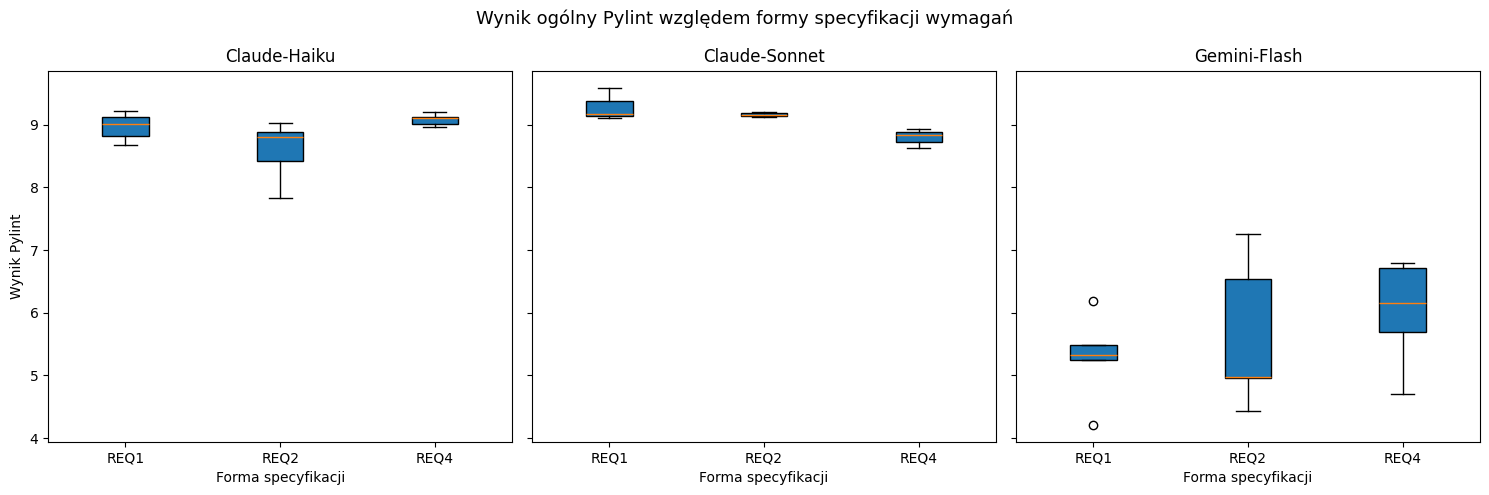

In [4]:
df = fleetrouter_static.copy()

agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']
req_forms = sorted(df['REQ'].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, am in zip(axes, agent_models):
    am_df = df[df['AgentModel'].str.lower() == am.lower()]
    groups = [am_df[am_df['REQ'] == req]['Pylint score'].dropna().values for req in req_forms]
    ax.boxplot(groups, labels=req_forms, patch_artist=True)
    ax.set_title(am)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Wynik Pylint')

fig.suptitle('Wynik ogólny Pylint względem formy specyfikacji wymagań', fontsize=13)
plt.tight_layout()
plt.show()

### Barplot - SonarQube Maintainability względem formy specyfikacji

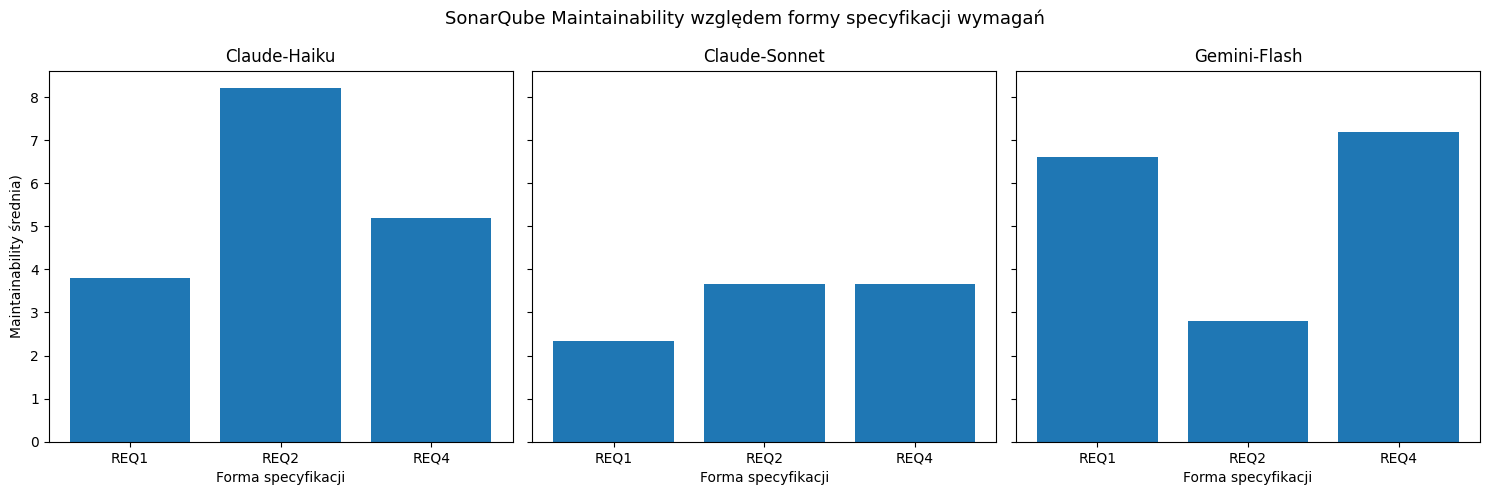

In [5]:
df = fleetrouter_static.copy()

agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']
req_forms = sorted(df['REQ'].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, am in zip(axes, agent_models):
    am_df = df[df['AgentModel'].str.lower() == am.lower()]
    means = [am_df[am_df['REQ'] == req]['Maintainability_summary'].dropna().mean() for req in req_forms]
    ax.bar(req_forms, means)
    ax.set_title(am)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Maintainability średnia)')

fig.suptitle('SonarQube Maintainability względem formy specyfikacji wymagań', fontsize=13)
plt.tight_layout()
plt.show()

### Wykres zbiorczy

In [ ]:
df = fleetrouter_static.copy()
df['SonarQube_total'] = df['Security_summary'] + df['Reliability_summary'] + df['Maintainability_summary']
req_forms = sorted(df['REQ'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pylint
groups_pylint = [df[df['REQ'] == req]['Pylint score'].dropna().values for req in req_forms]
axes[0].boxplot(groups_pylint, labels=req_forms, patch_artist=True)
axes[0].set_title('Pylint')
axes[0].set_ylabel('Wynik Pylint')
axes[0].set_xlabel('Forma specyfikacji')

# SonarQube
means_sonar = [df[df['REQ'] == req]['SonarQube_total'].dropna().mean() for req in req_forms]
axes[1].bar(req_forms, means_sonar)
axes[1].set_title('SonarQube')
axes[1].set_ylabel('Średnia liczba problemów SonarQube')
axes[1].set_xlabel('Forma specyfikacji')

fig.suptitle('Wyniki zbiorcze według formy specyfikacji wymagań', fontsize=13)
plt.tight_layout()
plt.show()

## Analiza zużycia tokenów

### Sumaryczne zużycie tokenów względem formy specyfikacji

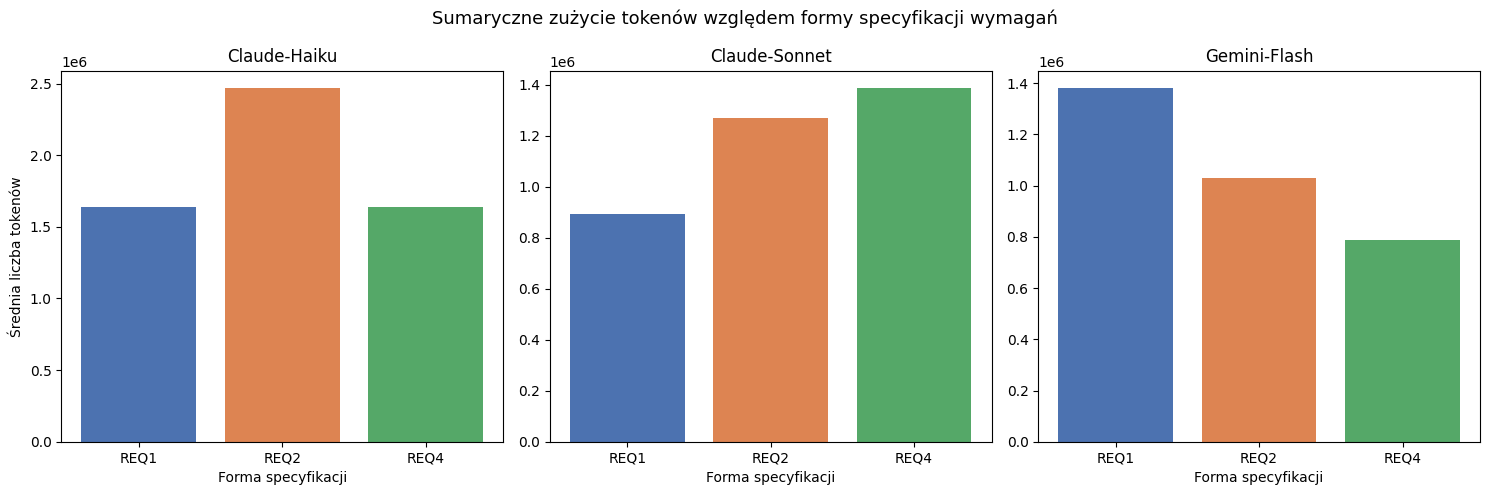

In [7]:
df = fleetrouter_static.copy()
# Kolumna 'Cache_create_tokens' = suma wszystkich tokenów (Tokens summary w CSV; nazwy przesunięte o 1)

agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']
req_forms = sorted(df['REQ'].dropna().unique())
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, am in zip(axes, agent_models):
    am_df = df[df['AgentModel'].str.lower() == am.lower()]
    means = [am_df[am_df['REQ'] == req]['Cache_create_tokens'].dropna().mean() for req in req_forms]
    ax.bar(req_forms, means, color=colors[:len(req_forms)])
    ax.set_title(am)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Średnia liczba tokenów')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

fig.suptitle('Sumaryczne zużycie tokenów względem formy specyfikacji wymagań', fontsize=13)
plt.tight_layout()
plt.show()

### Zbiorcze zużycie tokenów (boxplot)

/tmp/ipykernel_93199/1248901444.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=req_forms, patch_artist=True)


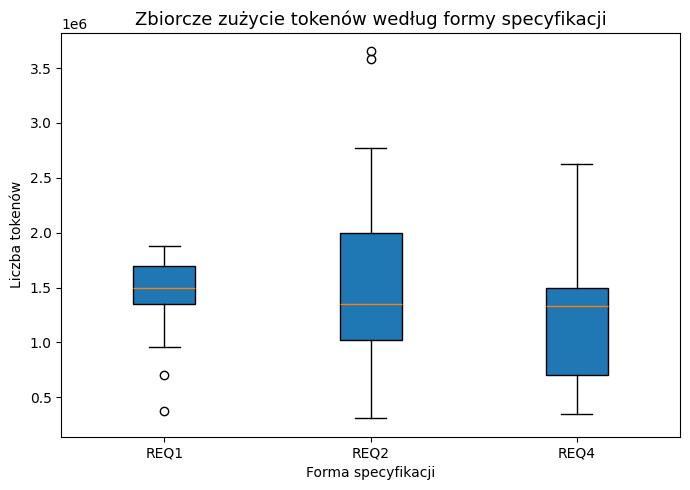

In [8]:
df = fleetrouter_static.copy()
req_forms = sorted(df['REQ'].dropna().unique())

fig, ax = plt.subplots(figsize=(7, 5))
groups = [df[df['REQ'] == req]['Cache_create_tokens'].dropna().values for req in req_forms]
ax.boxplot(groups, labels=req_forms, patch_artist=True)
ax.set_title('Zbiorcze zużycie tokenów według formy specyfikacji', fontsize=13)
ax.set_ylabel('Liczba tokenów')
ax.set_xlabel('Forma specyfikacji')
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.tight_layout()
plt.show()

### Związek między zużyciem tokenów a wynikiem Pylint

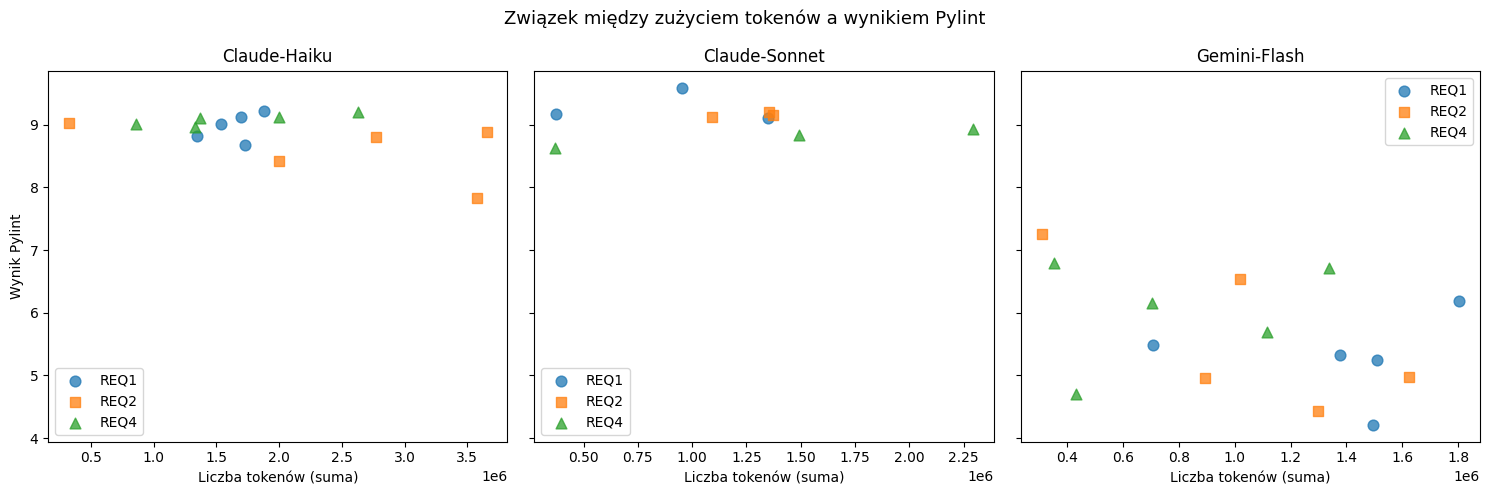

In [9]:
df = fleetrouter_static.copy()

agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']
markers = {'REQ1': 'o', 'REQ2': 's', 'REQ4': '^'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, am in zip(axes, agent_models):
    am_df = df[df['AgentModel'].str.lower() == am.lower()].dropna(
        subset=['Cache_create_tokens', 'Pylint score'])
    for req in sorted(am_df['REQ'].dropna().unique()):
        sub = am_df[am_df['REQ'] == req]
        ax.scatter(sub['Cache_create_tokens'], sub['Pylint score'],
                   label=req, marker=markers.get(req, 'o'), alpha=0.75, s=60)
    ax.set_title(am)
    ax.set_xlabel('Liczba tokenów (suma)')
    if ax == axes[0]:
        ax.set_ylabel('Wynik Pylint')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    ax.legend()

fig.suptitle('Związek między zużyciem tokenów a wynikiem Pylint', fontsize=13)
plt.tight_layout()
plt.show()

### Związek między zużyciem tokenów a liczbą problemów SonarQube

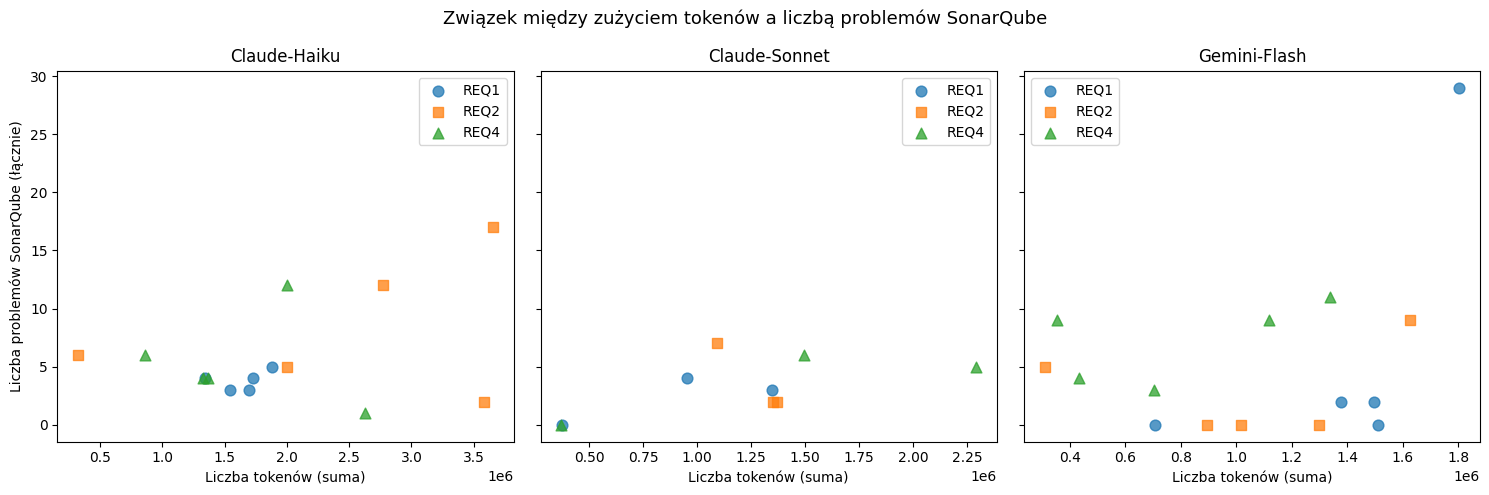

In [10]:
df = fleetrouter_static.copy()
df['SonarQube_total'] = df['Security_summary'] + df['Reliability_summary'] + df['Maintainability_summary']

agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']
markers = {'REQ1': 'o', 'REQ2': 's', 'REQ4': '^'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, am in zip(axes, agent_models):
    am_df = df[df['AgentModel'].str.lower() == am.lower()].dropna(
        subset=['Cache_create_tokens', 'SonarQube_total'])
    for req in sorted(am_df['REQ'].dropna().unique()):
        sub = am_df[am_df['REQ'] == req]
        ax.scatter(sub['Cache_create_tokens'], sub['SonarQube_total'],
                   label=req, marker=markers.get(req, 'o'), alpha=0.75, s=60)
    ax.set_title(am)
    ax.set_xlabel('Liczba tokenów (suma)')
    if ax == axes[0]:
        ax.set_ylabel('Liczba problemów SonarQube (łącznie)')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    ax.legend()

fig.suptitle('Związek między zużyciem tokenów a liczbą problemów SonarQube', fontsize=13)
plt.tight_layout()
plt.show()

## Analiza funkcjonalna

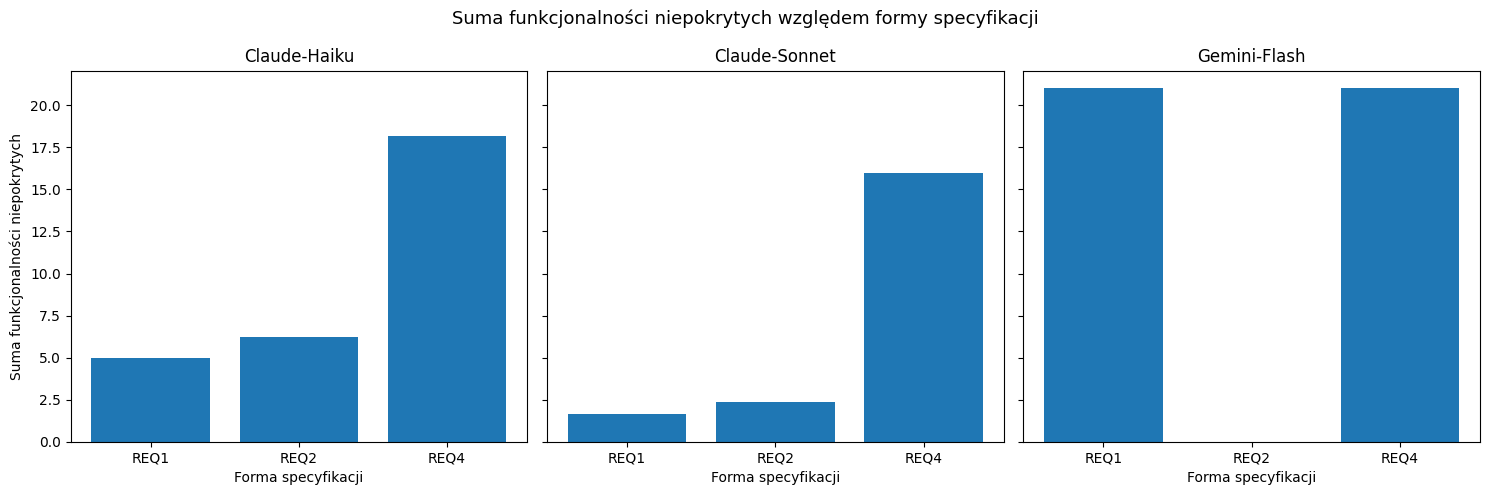

In [11]:
df = fleetrouter_functional.copy()

agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']
req_forms = sorted(df['REQ'].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, am in zip(axes, agent_models):
    am_df = df[df['AgentModel'].str.lower() == am.lower()]
    means = [am_df[am_df['REQ'] == req]['Total failures'].dropna().mean() for req in req_forms]
    ax.bar(req_forms, means)
    ax.set_title(am)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Suma funkcjonalności niepokrytych')

fig.suptitle('Suma funkcjonalności niepokrytych względem formy specyfikacji', fontsize=13)
plt.tight_layout()
plt.show()

### Wykres zbiorczy – rozkład błędów per scenariusz

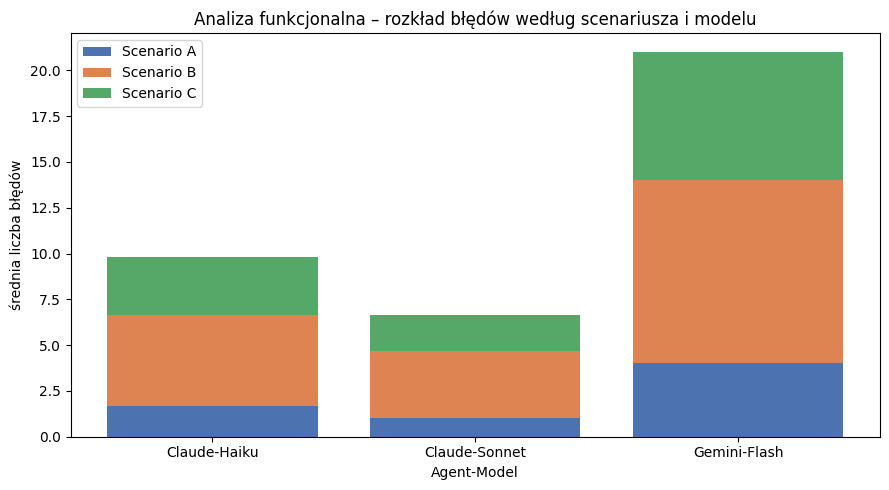

In [12]:
df = fleetrouter_functional.copy()
agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']

means_a = [df[df['AgentModel'].str.lower() == am.lower()]['ScenarioA'].dropna().mean() for am in agent_models]
means_b = [df[df['AgentModel'].str.lower() == am.lower()]['ScenarioB'].dropna().mean() for am in agent_models]
means_c = [df[df['AgentModel'].str.lower() == am.lower()]['ScenarioC'].dropna().mean() for am in agent_models]

x = range(len(agent_models))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, means_a, label='Scenario A', color='#4C72B0')
ax.bar(x, means_b, bottom=means_a, label='Scenario B', color='#DD8452')
ax.bar(x, means_c, bottom=[a + b for a, b in zip(means_a, means_b)], label='Scenario C', color='#55A868')

ax.set_xticks(list(x))
ax.set_xticklabels(agent_models)
ax.set_ylabel('średnia liczba błędów')
ax.set_xlabel('Agent-Model')
ax.legend()
ax.set_title('Analiza funkcjonalna – rozkład błędów według scenariusza i modelu')
plt.tight_layout()
plt.show()

### Heatmapa – średnie Total failures (AgentModel × forma specyfikacji)

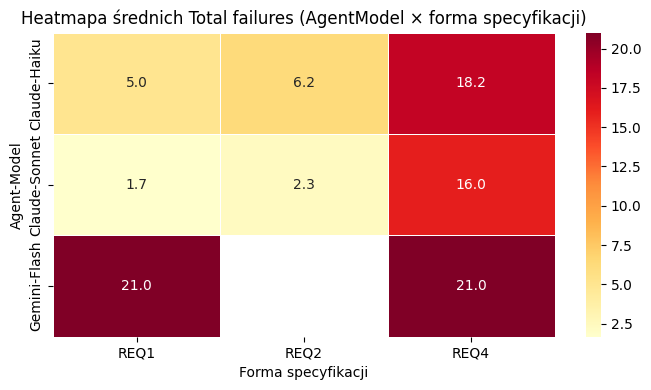

In [13]:
df = fleetrouter_functional.copy()
agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']
req_forms = sorted(df['REQ'].dropna().unique())

matrix = [
    [df[(df['AgentModel'].str.lower() == am.lower()) & (df['REQ'] == req)]['Total failures'].dropna().mean()
     for req in req_forms]
    for am in agent_models
]

heat_df = pd.DataFrame(matrix, index=agent_models, columns=req_forms)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmapa średnich Total failures (AgentModel × forma specyfikacji)')
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Agent-Model')
plt.tight_layout()
plt.show()